In [31]:
from core.reader import load_experimental_data
from core.calculations import calculate_von_mises_stress

# CSV лежат в этой же папке, что и ноутбук. Ядро должно иметь cwd = P29/experimental_vint.
# Если cwd — корень репозитория, замените на: real_experiment_data_folder = "P29/experimental_vint"
real_experiment_data_folder = "."
real_experiment = load_experimental_data(real_experiment_data_folder)
real_experiment = calculate_von_mises_stress(
            real_experiment,
            s_x_col='S_TT',
            s_y_col='S_ZZ',
            s_xy_col='S_TZ',
            new_col_name='S_EQV'
        )

In [32]:
from core.reader import read_ansys_csv

numerical_experiment_voce_hardernng = read_ansys_csv("voce_hardening.csv")

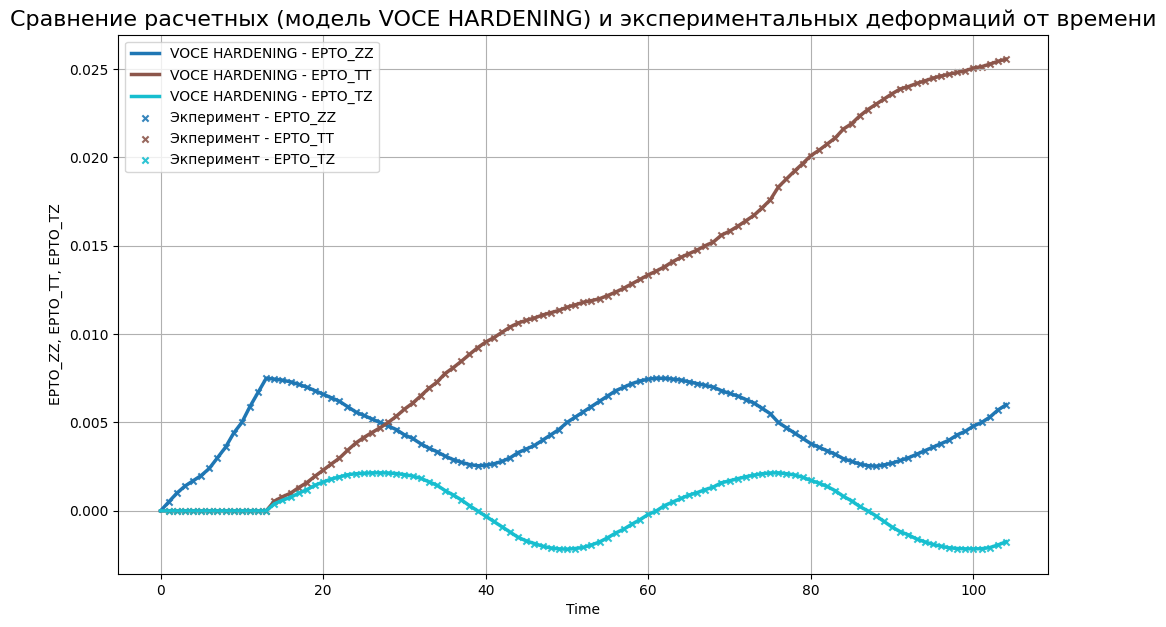

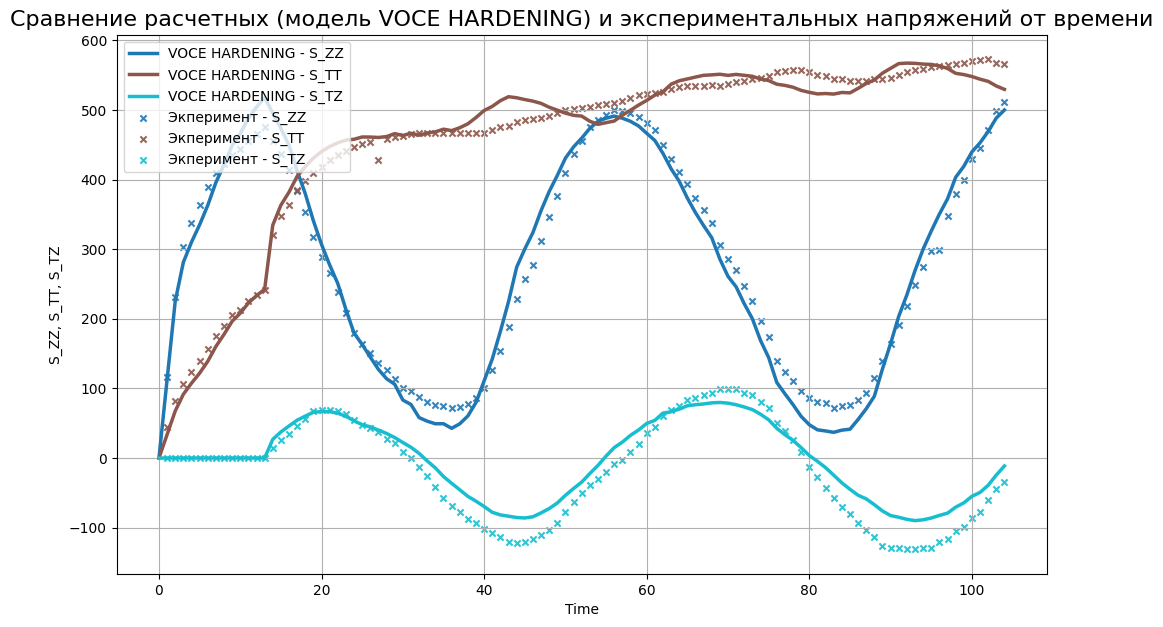

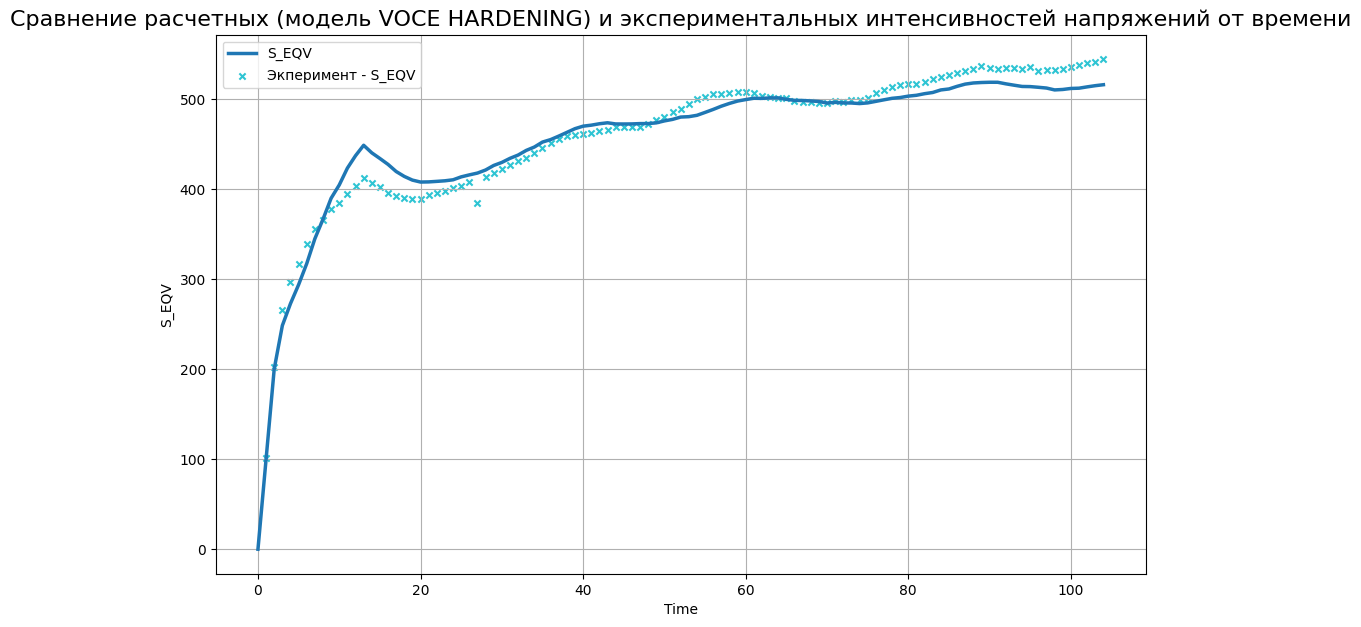

In [33]:
from core.visualizer import plot_xy

model_name = 'VOCE HARDENING'
plot_xy([
        (model_name, numerical_experiment_voce_hardernng)
    ],
    'Time',
    ['EPTO_ZZ', 'EPTO_TT', 'EPTO_TZ'],
    f'Сравнение расчетных (модель {model_name}) и экспериментальных деформаций от времени',
    ('Экперимент', real_experiment),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_voce_hardernng)
    ],
    'Time',
    ['S_ZZ', 'S_TT', 'S_TZ'],
    f'Сравнение расчетных (модель {model_name}) и экспериментальных напряжений от времени',
    ('Экперимент', real_experiment),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_voce_hardernng)
    ],
    'Time',
    ['S_EQV'],
    f'Сравнение расчетных (модель {model_name}) и экспериментальных интенсивностей напряжений от времени',
    ('Экперимент', real_experiment),
    figsize=(12, 7)
)

### Сравнительный анализ векторов напряжений Ильюшина

Для оценки достоверности численной модели проведем сравнение вектора напряжений $\vec{\sigma}_{mc}$ (ANSYS) и вектора $\vec{\sigma}_{exp}$ (эксперимент) в пятимерном пространстве напряжений Ильюшина. Расчет выполнен по следующим критериям:

#### 1. Угловое рассогласование ($\varphi$)
Определяет точность предсказания **направления** процесса деформирования. Угол между векторами вычисляется через скалярное произведение:
$$\varphi = \arccos\left(\frac{\vec{\sigma}_{mc} \cdot \vec{\sigma}_{exp}}{|\vec{\sigma}_{mc}| \cdot |\vec{\sigma}_{exp}|}\right)$$
*Значение $\varphi = 0$ соответствует полному совпадению направлений векторов.*

#### 2. Относительная погрешность модуля ($\text{Error}$)
Определяет точность расчета **амплитуды** (интенсивности) напряжений:
$$\text{Error} = \frac{|\vec{\sigma}_{mc} - \vec{\sigma}_{exp}|}{|\vec{\sigma}_{mc}|}$$

In [34]:
split_time_exp = 14.0

df_exp_stage2 = real_experiment[real_experiment["Time"] > split_time_exp].copy()
df_exp_stage2.reset_index(drop=True, inplace=True)
df_exp_stage2["Time_Local"] = df_exp_stage2["Time"] - df_exp_stage2["Time"].iloc[0]
df_exp_stage2["Sigma_Mean"] = (df_exp_stage2["S_ZZ"] + df_exp_stage2["S_TT"]) / 3.0

numerical_experiment_stage2 = numerical_experiment_voce_hardernng[numerical_experiment_voce_hardernng["Time"] > split_time_exp].copy()
numerical_experiment_stage2.reset_index(drop=True, inplace=True)
numerical_experiment_stage2["Time_Local"] = numerical_experiment_stage2["Time"] - numerical_experiment_stage2["Time"].iloc[0]

In [35]:
from core.calculations import calculate_stress_vector


sig_1, sig_2, sig_3 = calculate_stress_vector(df_exp_stage2)
df_exp_stage2["Sig_1"] = sig_1
df_exp_stage2["Sig_2"] = sig_2
df_exp_stage2["Sig_3"] = sig_3

sig_1, sig_2, sig_3 = calculate_stress_vector(numerical_experiment_stage2)
numerical_experiment_stage2["Sig_1"] = sig_1
numerical_experiment_stage2["Sig_2"] = sig_2
numerical_experiment_stage2["Sig_3"] = sig_3

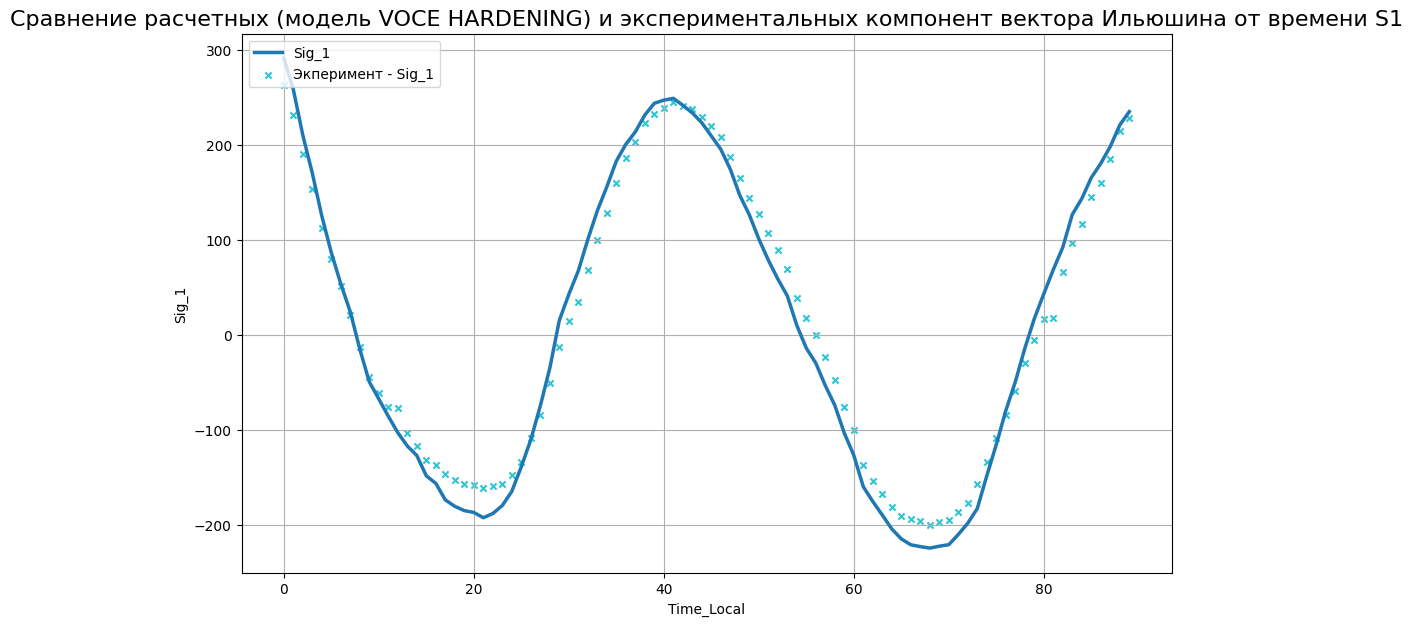

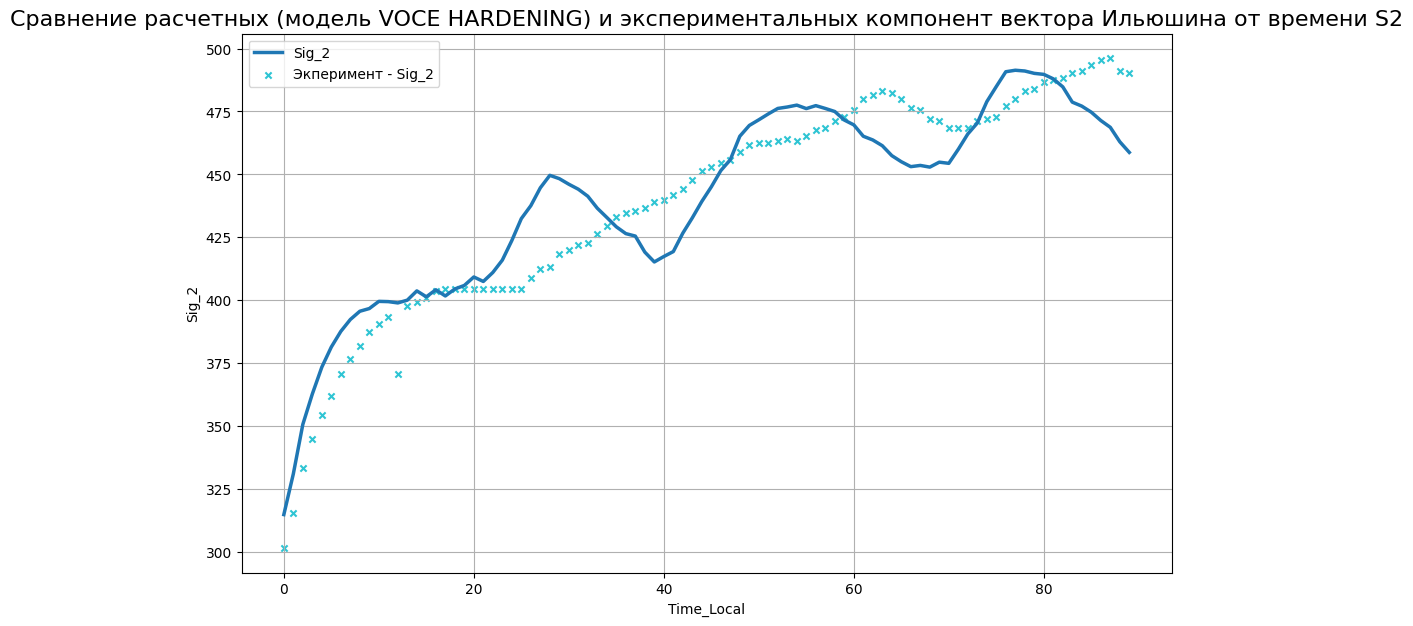

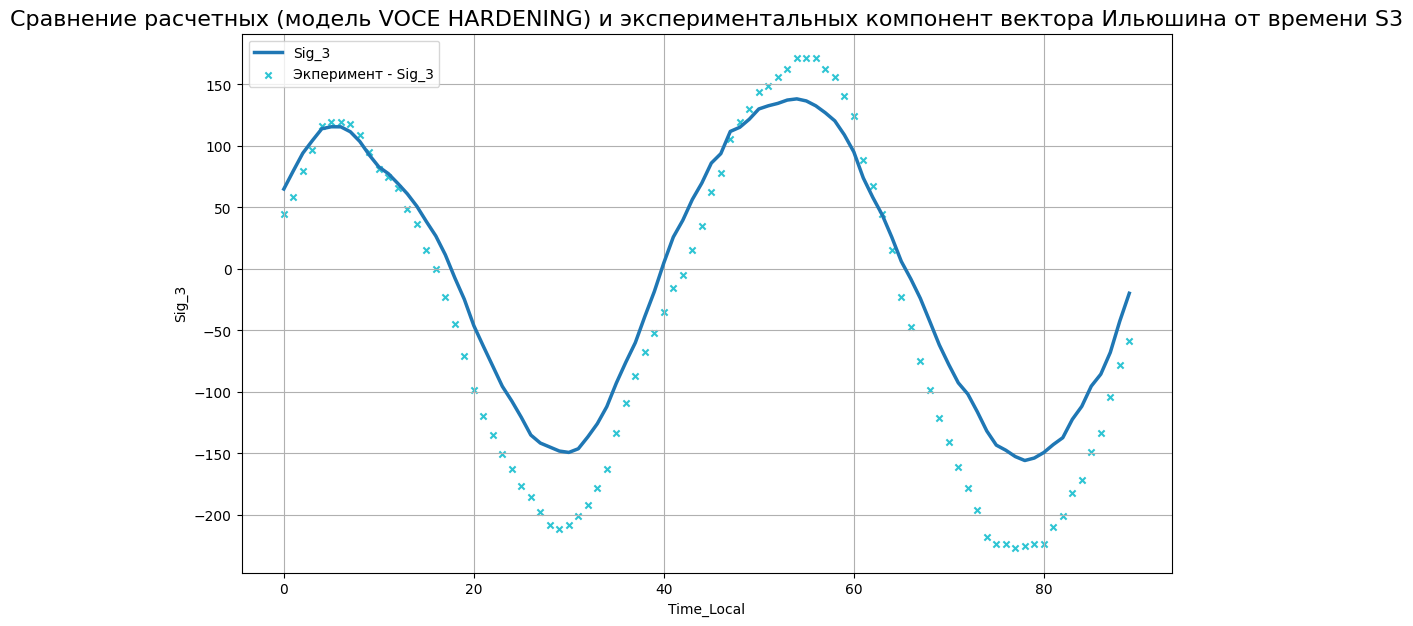

In [36]:
plot_xy([
        (model_name, numerical_experiment_stage2)
    ],
    "Time_Local",
    ["Sig_1"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных компонент вектора Ильюшина от времени S1",
    ("Экперимент", df_exp_stage2),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_stage2)
    ],
    "Time_Local",
    ["Sig_2"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных компонент вектора Ильюшина от времени S2",
    ("Экперимент", df_exp_stage2),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_stage2)
    ],
    "Time_Local",
    ["Sig_3"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных компонент вектора Ильюшина от времени S3",
    ("Экперимент", df_exp_stage2),
    figsize=(12, 7)
)

In [37]:
from core.calculations import merge_and_compare_ilushin_stress

df = merge_and_compare_ilushin_stress(
    numerical_experiment_stage2,
    df_exp_stage2,
    on="Time_Local",
)

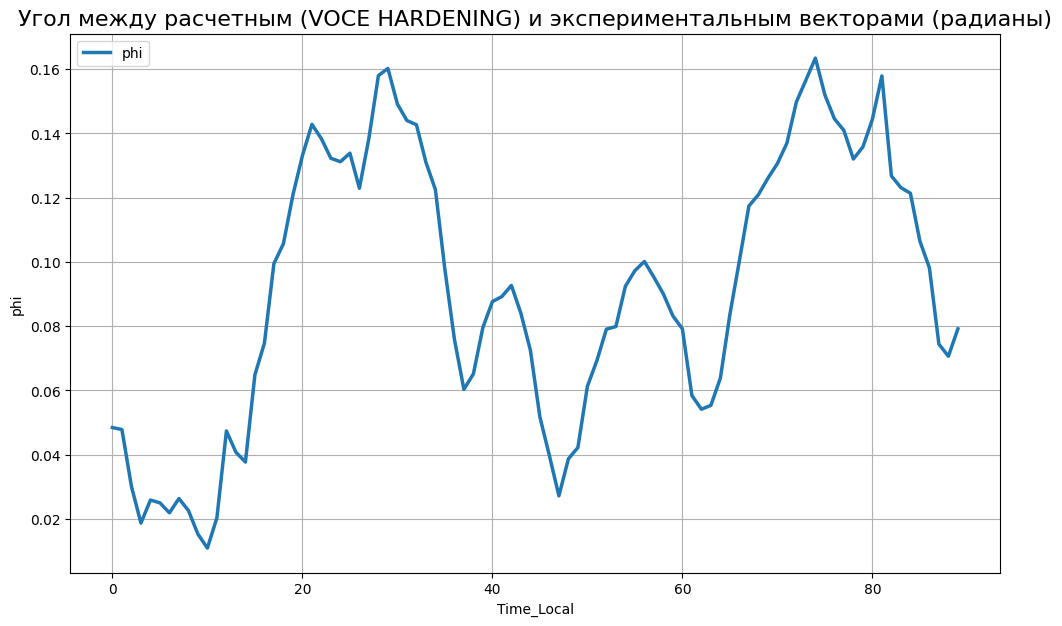

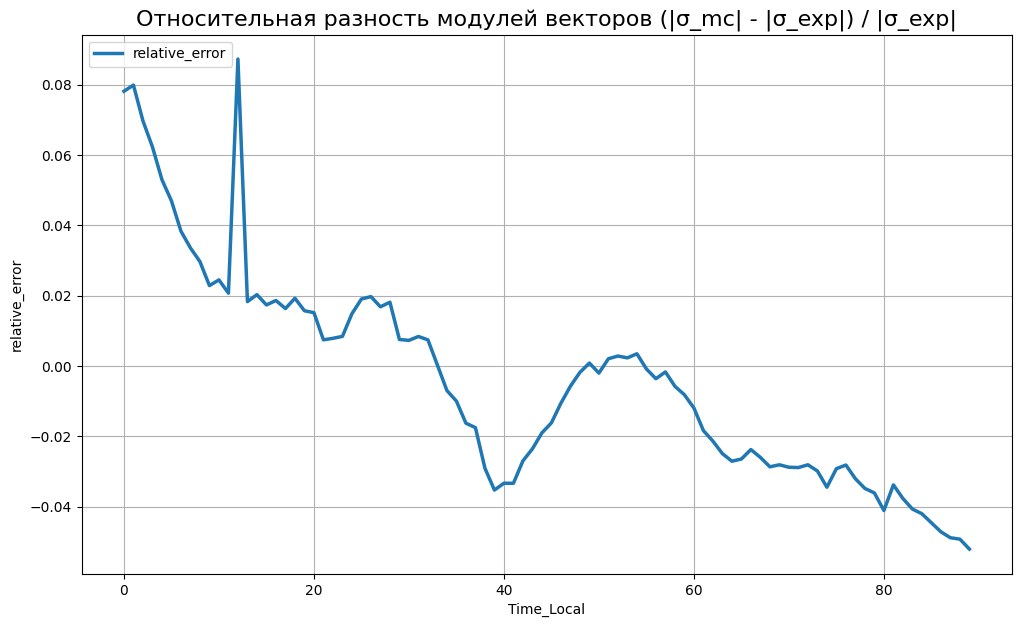

In [38]:
plot_xy(
    data_pairs=[(model_name, df)],
    x_col="Time_Local",
    y_cols=["phi"],
    title=f"Угол между расчетным ({model_name}) и экспериментальным векторами (радианы)",
    figsize=(12, 7)
)

plot_xy(
    data_pairs=[(model_name, df)],
    x_col="Time_Local",
    y_cols=["relative_error"],
    title=f"Относительная разность модулей векторов (|σ_mc| - |σ_exp|) / |σ_exp|",
    figsize=(12, 7)
)

#### Выводы по результатам сравнения:
*   **Идентичность графиков:** Наблюдается совпадение профилей угла $\varphi$ и относительной ошибки. Это обусловлено тем, что при малых отклонениях ($< 0.2$ рад) длина хорды между концами векторов пропорциональна углу между ними.
*   **Точность модели:** Максимальное отклонение не превышает **0.16**.